# Optical wave gauging: Marconi, with a temporal holdback for unbiased skill assessment
csherwood@usgs.gov, 2026-09-25, generated with Sonnet 5

Extends `OWG_train_pytorch_v2.ipynb` (Duck NC) with three changes aimed at an honest skill assessment on the Marconi data:

1. **Temporal holdback, set aside before anything else.** `HOLD_START`/`HOLD_END` (picked in `plot_marconi_wave_timeseries.ipynb`) mark a contiguous block of time that never enters training, validation, or the bin-balanced oversampling. Consecutive hourly images are strongly autocorrelated, so a random image-level split (as in v2) leaks information between train and validation; a block holdout does not.
2. **Oversampling applied only to the training split.** v2 oversampled before splitting, so duplicated images could land in both train and validation, inflating validation R2. Here the remaining (non-holdback) pool is split into train/val first, and only `train_df` is bin-balanced.
3. **The holdback is touched exactly once**, after training and early stopping are both finished, purely for reporting. Validation (from the pool) is what early stopping watches; the holdback never influences a single weight update or hyperparameter choice.

Optionally loads the Duck-trained weights (`owg_out/owg_{category}_{BACKBONE}.pt`) as a transfer-learning starting point; set `PRETRAINED_DIR = None` for a plain ImageNet start.

Reference for the underlying approach: Buscombe et al. (2019), *Optical wave gauging using deep neural networks*, Coastal Engineering 150, 103593, https://doi.org/10.1016/j.coastaleng.2019.103593.

In [1]:
# csherwood@usgs.gov, 2026-09-25, generated with Sonnet 5

# data
IMAGE_DIR = r"F:\crs\proj\2026_owg\marconi_imagery\c2\c2"
CSV_PATH  = r"F:\crs\proj\2026_owg\Marconi-Training-Oblique-cam2-snap.csv"

# holdback interval - set from plot_marconi_wave_timeseries.ipynb
HOLD_START = "2025-02-15"   # inclusive, UTC
HOLD_END   = "2025-03-01"   # inclusive, UTC

CATEGORIES     = ["H", "T"]
IMG_SIZE       = 224
BACKBONE       = "convnext_tiny"
TEST_SIZE      = 0.2                  # val fraction, drawn from the pool (non-holdback) data only
BALANCE_BY_CATEGORY = True
BATCH_SIZE     = 32
NUM_EPOCHS     = 40
FREEZE_EPOCHS  = 0                    # 0 if PRETRAINED_DIR is set (backbone already surf-zone adapted)
LR_HEAD        = 1e-3
LR_FINETUNE    = 3e-5                 # gentler than a from-scratch run when starting from adapted weights
WEIGHT_DECAY   = 1e-4
PATIENCE       = 10
NUM_WORKERS    = 0
DEVICE_H       = "cuda:0"
DEVICE_T       = "cuda:1"             # set equal to DEVICE_H if only 1 GPU
RANDOM_STATE   = 2018

PRETRAINED_DIR = None #"owg_out_buscombe"            # Duck weights; set to None for a plain ImageNet start
OUT_DIR        = "owg_out_marconi"

In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from PIL import Image
import timm

os.makedirs(OUT_DIR, exist_ok=True)
print(torch.__version__, "cuda available:", torch.cuda.is_available(), "device count:", torch.cuda.device_count())

2.14.0+cu126 cuda available: True device count: 2


In [3]:
assert os.path.exists(CSV_PATH), f"missing {CSV_PATH}"
assert os.path.isdir(IMAGE_DIR), f"missing {IMAGE_DIR}"

df = pd.read_csv(CSV_PATH)
df = df.rename(columns=lambda c: c.strip())
df["path"] = df["id"].map(lambda x: os.path.join(IMAGE_DIR, x))
df = df[df["path"].map(os.path.exists)].dropna().reset_index(drop=True)
df["epoch"] = df["id"].map(lambda x: int(x.split(".")[0]))
df["time"] = pd.to_datetime(df["epoch"], unit="s", utc=True)
df = df.sort_values("time").reset_index(drop=True)
print(df.shape, df["time"].min(), "to", df["time"].max())

(1429, 6) 2024-12-20 17:00:00+00:00 to 2025-03-10 15:00:00+00:00


## Split: holdback first, then train/val

`holdback_df` is a single contiguous block, never resampled or touched again until final evaluation. `pool_df` (everything else) is what training, validation, and oversampling draw from.

In [4]:
hold_start = pd.Timestamp(HOLD_START, tz="UTC")
hold_end   = pd.Timestamp(HOLD_END, tz="UTC")
in_hold = (df["time"] >= hold_start) & (df["time"] <= hold_end)

holdback_df = df[in_hold].reset_index(drop=True)
pool_df     = df[~in_hold].reset_index(drop=True)
print(f"holdback: {len(holdback_df)} images ({HOLD_START} to {HOLD_END})")
print(f"pool: {len(pool_df)} images for train+val")
assert len(holdback_df) > 0, "holdback interval matched no images - check HOLD_START/HOLD_END"

holdback: 309 images (2025-02-15 to 2025-03-01)
pool: 1120 images for train+val


## How much was withheld, and does it cover the same conditions?

Fraction of images withheld, and box plots comparing the wave-condition distribution
in the pool (training+validation) against the holdback. A holdback that is either a
tiny sliver of the record or covers a narrower range of sea states than the pool makes
the skill estimate less representative of how the model will perform in general.

In [5]:
n_total = len(df)
frac_images = len(holdback_df) / n_total
span_total = (df["time"].max() - df["time"].min())
frac_time = (hold_end - hold_start) / span_total
print(f"withheld: {len(holdback_df)}/{n_total} images ({frac_images:.1%})")
print(f"withheld time span: {hold_end - hold_start} of {span_total} total ({frac_time:.1%})")

for category in CATEGORIES:
    print(f"\n{category}:")
    print(pd.DataFrame({
        "pool": pool_df[category].describe(),
        "holdback": holdback_df[category].describe(),
    }))

withheld: 309/1429 images (21.6%)
withheld time span: 14 days 00:00:00 of 79 days 22:00:00 total (17.5%)

H:
              pool    holdback
count  1120.000000  309.000000
mean      1.028884    0.871489
std       0.507462    0.563157
min       0.170000    0.220000
25%       0.670000    0.420000
50%       0.950000    0.750000
75%       1.270000    1.050000
max       3.060000    3.160000

T:
              pool    holdback
count  1120.000000  309.000000
mean      7.285482    8.154693
std       2.233676    2.792423
min       2.390000    3.000000
25%       5.590000    5.850000
50%       6.600000    7.350000
75%       8.570000   10.300000
max      16.000000   16.000000


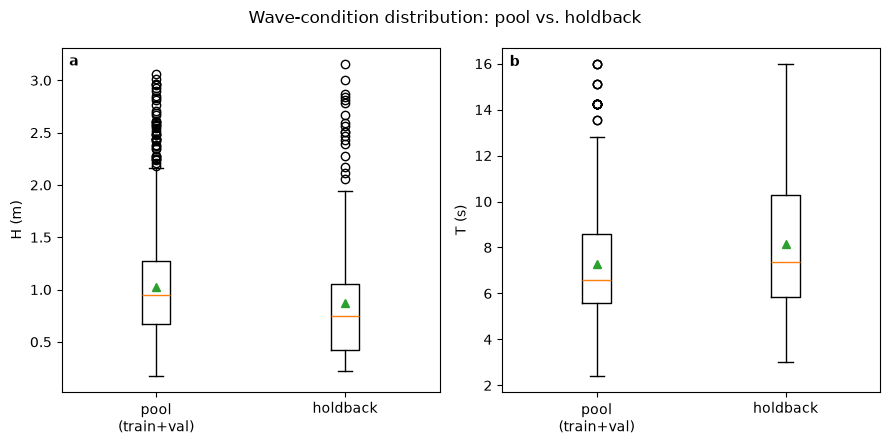

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
labels = ["a", "b"]
units = {"H": "m", "T": "s"}
for ax, category, label in zip(axs, CATEGORIES, labels):
    ax.boxplot([pool_df[category], holdback_df[category]],
               tick_labels=["pool\n(train+val)", "holdback"], showmeans=True)
    ax.set_ylabel(f"{category} ({units[category]})")
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
fig.suptitle("Wave-condition distribution: pool vs. holdback")
fig.tight_layout()

In [7]:
def balance_by_category(df, category, n_bins):
    # oversample by target-value bin so rare high/low sea states aren't swamped
    # by the common mid-range ones - applied to the training split ONLY
    bins = pd.cut(df[category], n_bins)
    n = len(df) // 2
    return (df.groupby(bins, observed=True)
              .apply(lambda g: g.sample(n, replace=True))
              .reset_index(drop=True))

In [8]:
class OWGDataset(Dataset):
    def __init__(self, df, category, img_size, train):
        self.paths = df["path"].values
        self.y = df[category].values.astype(np.float32)
        if train:
            self.tf = T.Compose([
                T.ToImage(), T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(),
                T.RandomAffine(degrees=10, translate=(0.1, 0.1), shear=5),
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.tf = T.Compose([
                T.ToImage(), T.Resize((img_size, img_size)),
                T.ToDtype(torch.float32, scale=True),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        x = self.tf(img)
        y = torch.tensor(self.y[idx])
        return x, y

In [9]:
def build_model(category):
    m = timm.create_model(BACKBONE, pretrained=PRETRAINED_DIR is None, num_classes=1)
    if PRETRAINED_DIR:
        state = torch.load(f"{PRETRAINED_DIR}/owg_{category}_{BACKBONE}.pt")
        m.load_state_dict(state)
    return m

def set_backbone_trainable(model, trainable):
    for name, p in model.named_parameters():
        if "head" not in name and "fc" not in name and "classifier" not in name:
            p.requires_grad = trainable

## Skill metrics

RMSE and MAE (physical units), bias (mean error, signed - systematic over/under-prediction),
R2, and Willmott's index of agreement $d$ (Willmott, 1981, *On the validation of models*,
Physical Geography 2(2), 184-194):

$$d = 1 - \frac{\sum (P_i - O_i)^2}{\sum (|P_i - \bar{O}| + |O_i - \bar{O}|)^2}$$

$d$ is bounded on $[0, 1]$ and, unlike $R^2$, penalizes a systematic bias even when the model
tracks the shape of the variability well - a useful cross-check when $R^2$ alone looks good.

In [10]:
def willmott_d(y_true, y_pred):
    obar = y_true.mean()
    num = np.sum((y_pred - y_true) ** 2)
    den = np.sum((np.abs(y_pred - obar) + np.abs(y_true - obar)) ** 2)
    return 1 - num / den

def skill_metrics(y_true, y_pred):
    return dict(
        rmse=np.sqrt(mean_squared_error(y_true, y_pred)),
        mae=mean_absolute_error(y_true, y_pred),
        bias=np.mean(y_pred - y_true),
        r2=r2_score(y_true, y_pred),
        willmott_d=willmott_d(y_true, y_pred),
        n=len(y_true),
    )

In [11]:
def train_owg(category, device):
    n_bins = 10 if category == "H" else 8

    # split the pool FIRST, then balance only the training half - avoids the
    # train/val leakage that oversample-then-split produces
    train_df, val_df = train_test_split(
        pool_df, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        stratify=pd.cut(pool_df[category], n_bins))
    if BALANCE_BY_CATEGORY:
        train_df = balance_by_category(train_df, category, n_bins)

    y_mean, y_std = train_df[category].mean(), train_df[category].std()

    train_ds = OWGDataset(train_df, category, IMG_SIZE, train=True)
    val_ds   = OWGDataset(val_df,   category, IMG_SIZE, train=False)
    hold_ds  = OWGDataset(holdback_df, category, IMG_SIZE, train=False)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    hold_dl  = DataLoader(hold_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_model(category).to(device)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(NUM_EPOCHS):
        finetune = epoch >= FREEZE_EPOCHS
        set_backbone_trainable(model, finetune)
        if epoch in (0, FREEZE_EPOCHS):
            opt = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=LR_FINETUNE if finetune else LR_HEAD, weight_decay=WEIGHT_DECAY)
            sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)

        model.train()
        tr_loss = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            y = (y - y_mean) / y_std
            opt.zero_grad()
            pred = model(x).squeeze(1)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(y)
        tr_loss /= len(train_ds)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                y = (y - y_mean) / y_std
                pred = model(x).squeeze(1)
                va_loss += loss_fn(pred, y).item() * len(y)
        va_loss /= len(val_ds)
        sched.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        print(f"[{category}] epoch {epoch:02d}  train_mse {tr_loss:.4f}  val_mse {va_loss:.4f}")

        if va_loss < best_val:
            best_val, best_state, bad_epochs = va_loss, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"[{category}] early stop at epoch {epoch}")
                break

    # early stopping picked the model on VAL loss only - holdback was never consulted
    model.load_state_dict(best_state)
    torch.save(best_state, f"{OUT_DIR}/owg_{category}_{BACKBONE}.pt")
    pd.Series({"mean": y_mean, "std": y_std}).to_json(f"{OUT_DIR}/owg_{category}_scale.json")

    def predict(dl, df_ref):
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in dl:
                pred = model(x.to(device)).squeeze(1).cpu().numpy()
                pred = pred * y_std + y_mean
                y_true.append(y.numpy()); y_pred.append(pred)
        return np.concatenate(y_true), np.concatenate(y_pred)

    val_true, val_pred = predict(val_dl, val_df)
    hold_true, hold_pred = predict(hold_dl, holdback_df)

    return dict(model=model, history=history,
                val_true=val_true, val_pred=val_pred,
                hold_true=hold_true, hold_pred=hold_pred,
                hold_time=holdback_df["time"].values)

In [ ]:
results = {}
devices = {"H": DEVICE_H, "T": DEVICE_T}
for category in CATEGORIES:
    device = devices[category] if torch.cuda.is_available() else "cpu"
    r = train_owg(category, device)
    r["val_metrics"]  = skill_metrics(r["val_true"],  r["val_pred"])
    r["hold_metrics"] = skill_metrics(r["hold_true"], r["hold_pred"])
    print(f"[{category}] val:      {r['val_metrics']}")
    print(f"[{category}] holdback: {r['hold_metrics']}")
    results[category] = r

[H] epoch 00  train_mse 0.2337  val_mse 0.0602
[H] epoch 01  train_mse 0.0304  val_mse 0.0399
[H] epoch 02  train_mse 0.0199  val_mse 0.0484
[H] epoch 03  train_mse 0.0126  val_mse 0.0309
[H] epoch 04  train_mse 0.0095  val_mse 0.0287
[H] epoch 05  train_mse 0.0079  val_mse 0.0297
[H] epoch 06  train_mse 0.0069  val_mse 0.0272
[H] epoch 07  train_mse 0.0048  val_mse 0.0261
[H] epoch 08  train_mse 0.0043  val_mse 0.0285
[H] epoch 09  train_mse 0.0042  val_mse 0.0271
[H] epoch 10  train_mse 0.0039  val_mse 0.0253
[H] epoch 11  train_mse 0.0036  val_mse 0.0247
[H] epoch 12  train_mse 0.0031  val_mse 0.0224
[H] epoch 13  train_mse 0.0038  val_mse 0.0221
[H] epoch 14  train_mse 0.0037  val_mse 0.0236
[H] epoch 15  train_mse 0.0025  val_mse 0.0234
[H] epoch 16  train_mse 0.0031  val_mse 0.0259
[H] epoch 17  train_mse 0.0022  val_mse 0.0234
[H] epoch 18  train_mse 0.0014  val_mse 0.0216
[H] epoch 19  train_mse 0.0012  val_mse 0.0207
[H] epoch 20  train_mse 0.0011  val_mse 0.0209
[H] epoch 21 

## Skill on the holdback

This is the number to report - it is the only evaluation the model never influenced, directly
or indirectly (no epoch was chosen, and no hyperparameter tuned, by looking at it). The
validation metrics above are shown for comparison; if holdback skill is much worse than
validation skill, that gap is itself informative - it means the pool's random split was
still leaking some autocorrelated structure, or the model doesn't generalize well to sea
states and imagery conditions outside the training window.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
labels = ["a", "b"]
units = {"H": "m", "T": "s"}
for ax, category, label in zip(axs, CATEGORIES, labels):
    r = results[category]
    m = r["hold_metrics"]
    lims = [min(r["hold_true"].min(), r["hold_pred"].min()), max(r["hold_true"].max(), r["hold_pred"].max())]
    ax.plot(r["hold_true"], r["hold_pred"], ".", alpha=0.5)
    ax.plot(lims, lims, "k-", lw=1)
    ax.set_xlabel(f"Observed {category} ({units[category]})")
    ax.set_ylabel(f"Predicted {category} ({units[category]})")
    ax.set_title(f"RMSE={m['rmse']:.3f} {units[category]}, bias={m['bias']:+.3f}, "
                 f"R2={m['r2']:.3f}, d={m['willmott_d']:.3f}")
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
fig.suptitle("Holdback skill (never used for training or early stopping)")
fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
labels = ["a", "b"]
for ax, category, label in zip(axs, CATEGORIES, labels):
    r = results[category]
    order = np.argsort(r["hold_time"])
    t = pd.to_datetime(r["hold_time"])[order]
    ax.plot(t, r["hold_true"][order], ".-", label="observed", ms=4)
    ax.plot(t, r["hold_pred"][order], ".-", label="predicted", ms=4)
    ax.set_ylabel(f"{category} ({units[category]})")
    ax.text(0.01, 0.95, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
    ax.legend(loc="upper right")
axs[-1].set_xlabel("time (UTC)")
fig.suptitle("Holdback time series: observed vs. predicted")
fig.tight_layout()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
labels = ["a", "b"]
for ax, category, label in zip(axs, CATEGORIES, labels):
    h = results[category]["history"]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (z-score units)")
    ax.set_title(category)
    ax.legend()
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
fig.tight_layout()

In [ ]:
summary = pd.DataFrame({cat: results[cat]["hold_metrics"] for cat in CATEGORIES}).T
summary.to_csv(f"{OUT_DIR}/holdback_skill_summary.csv")
summary